In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix


Read dataset

In [14]:
df=pd.read_csv(r'C:\Users\aalma\Downloads\dataset-uciCSV.csv')
df.head()

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,Body Mass Index (BMI),Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg),Hepatic Fat Accumulation (HFA),Glucose,Total Cholesterol (TC),Low Density Lipoprotein (LDL),High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,27.1,52.9,21.2,31.7,40.0,19.2,80.84,18.88,9,3.7,71.4,23.4,17.8,10.6,39.7,0,102.0,250.0,175.0,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,30.5,43.1,19.5,23.6,45.0,32.8,67.20,16.68,15,3.2,60.3,38.8,31.0,18.4,32.7,0,94.0,172.0,108.0,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,31.2,47.2,20.1,27.1,43.0,27.3,72.67,16.35,15,3.3,62.9,41.7,24.9,16.2,34.0,0,103.0,179.0,124.0,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,24.0,41.4,17.0,24.4,41.0,15.8,84.19,16.90,6,2.9,54.1,9.0,10.7,6.5,29.2,1,69.0,173.0,73.0,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,28.3,51.4,20.0,31.4,39.0,20.0,80.02,16.81,8,3.5,68.2,28.6,17.9,10.4,37.4,2,109.0,205.0,154.0,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


In [15]:
df.columns

Index(['Gallstone Status', 'Age', 'Gender', 'Comorbidity',
       'Coronary Artery Disease (CAD)', 'Hypothyroidism', 'Hyperlipidemia',
       'Diabetes Mellitus (DM)', 'Height', 'Weight', 'Body Mass Index (BMI)',
       'Total Body Water (TBW)', 'Extracellular Water (ECW)',
       'Intracellular Water (ICW)',
       'Extracellular Fluid/Total Body Water (ECF/TBW)',
       'Total Body Fat Ratio (TBFR) (%)', 'Lean Mass (LM) (%)',
       'Body Protein Content (Protein) (%)', 'Visceral Fat Rating (VFR)',
       'Bone Mass (BM)', 'Muscle Mass (MM)', 'Obesity (%)',
       'Total Fat Content (TFC)', 'Visceral Fat Area (VFA)',
       'Visceral Muscle Area (VMA) (Kg)', 'Hepatic Fat Accumulation (HFA)',
       'Glucose', 'Total Cholesterol (TC)', 'Low Density Lipoprotein (LDL)',
       'High Density Lipoprotein (HDL)', 'Triglyceride',
       'Aspartat Aminotransferaz (AST)', 'Alanin Aminotransferaz (ALT)',
       'Alkaline Phosphatase (ALP)', 'Creatinine',
       'Glomerular Filtration Rate (GFR

Show shape

In [16]:
df.shape

(319, 39)

In [17]:
df.describe

<bound method NDFrame.describe of      Gallstone Status  Age  ...  Hemoglobin (HGB)  Vitamin D
0                   0   50  ...              16.0       33.0
1                   0   47  ...              14.4       25.0
2                   0   61  ...              16.2       30.2
3                   0   41  ...              15.4       35.4
4                   0   42  ...              16.8       40.6
..                ...  ...  ...               ...        ...
314                 1   49  ...              16.5        8.3
315                 1   31  ...              12.5       24.0
316                 1   58  ...              15.4       15.7
317                 1   37  ...              16.0       33.3
318                 1   60  ...              13.6       29.0

[319 rows x 39 columns]>

## Data Cleaning

Check nulls

In [18]:
df.isnull().sum()

Gallstone Status                                  0
Age                                               0
Gender                                            0
Comorbidity                                       0
Coronary Artery Disease (CAD)                     0
Hypothyroidism                                    0
Hyperlipidemia                                    0
Diabetes Mellitus (DM)                            0
Height                                            0
Weight                                            0
Body Mass Index (BMI)                             0
Total Body Water (TBW)                            0
Extracellular Water (ECW)                         0
Intracellular Water (ICW)                         0
Extracellular Fluid/Total Body Water (ECF/TBW)    0
Total Body Fat Ratio (TBFR) (%)                   0
Lean Mass (LM) (%)                                0
Body Protein Content (Protein) (%)                0
Visceral Fat Rating (VFR)                         0
Bone Mass (B

Check types

In [19]:
df.dtypes

Gallstone Status                                    int64
Age                                                 int64
Gender                                              int64
Comorbidity                                         int64
Coronary Artery Disease (CAD)                       int64
Hypothyroidism                                      int64
Hyperlipidemia                                      int64
Diabetes Mellitus (DM)                              int64
Height                                              int64
Weight                                            float64
Body Mass Index (BMI)                             float64
Total Body Water (TBW)                            float64
Extracellular Water (ECW)                         float64
Intracellular Water (ICW)                         float64
Extracellular Fluid/Total Body Water (ECF/TBW)    float64
Total Body Fat Ratio (TBFR) (%)                   float64
Lean Mass (LM) (%)                                float64
Body Protein C

Outliers  

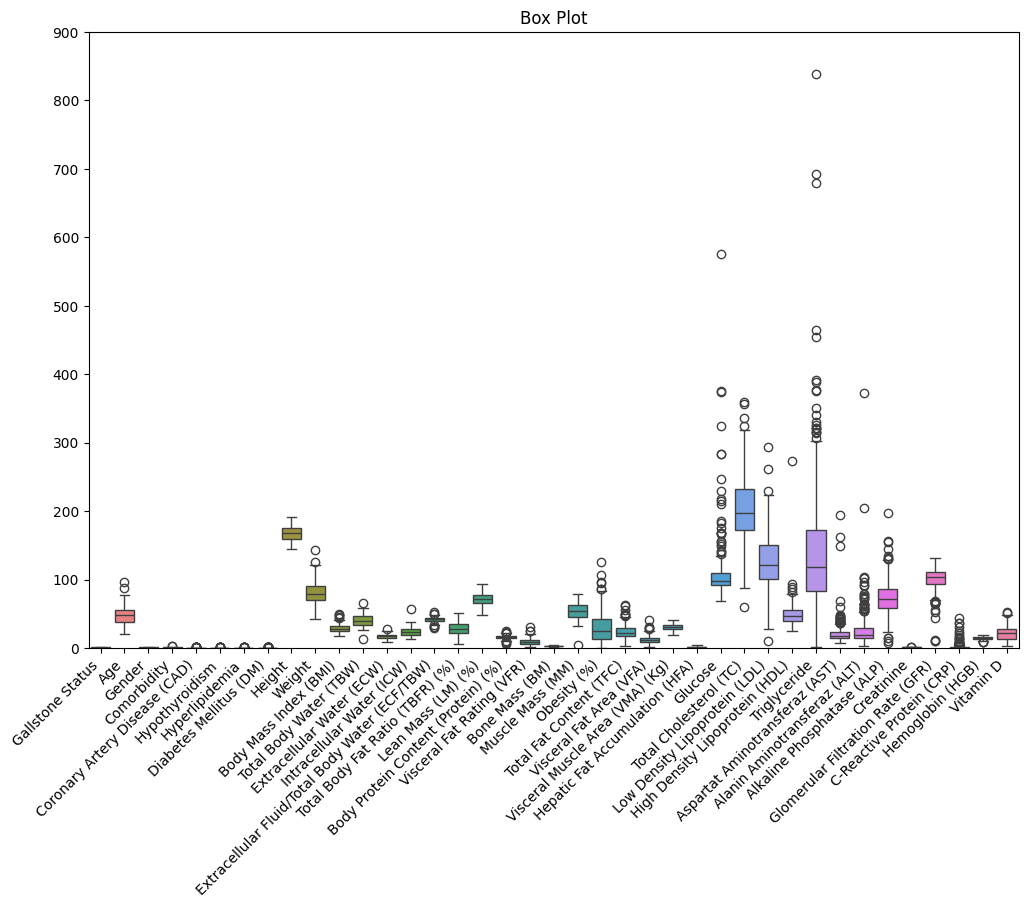

In [28]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df, width=0.8)
plt.xticks(rotation=45, ha='right')
plt.ylim(0,900)
plt.title("Box Plot")
plt.show()

In [29]:
for i in df.columns:
    Q1= df[i].quantile(0.25)
    Q3= df[i].quantile(0.75)
    IQR= Q3-Q1
    LOWER= Q1 - 1.5*IQR
    UPPER= Q3 + 1.5*IQR

    df[i]= df[i].clip(lower=LOWER, upper=UPPER)

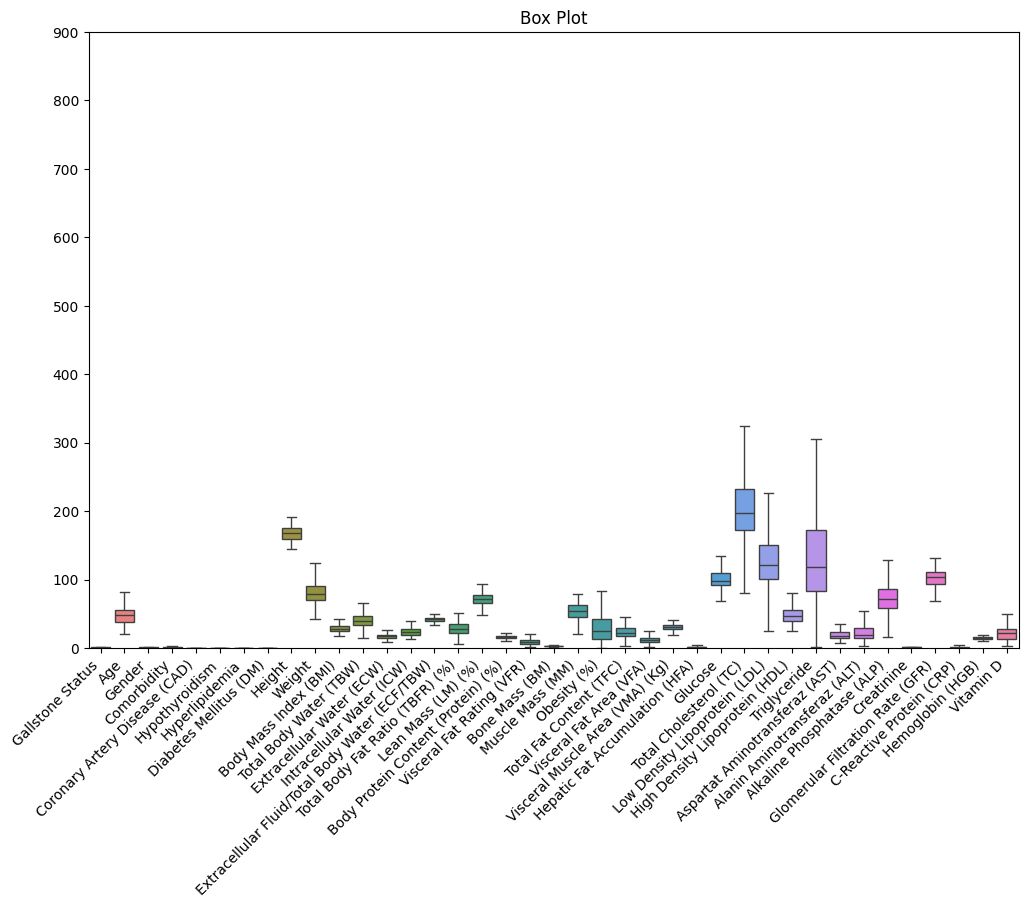

No Outliers


In [30]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df, width=0.8)
plt.xticks(rotation=45, ha='right')
plt.ylim(0,900)
plt.title("Box Plot")
plt.show()

Removing_flag= True
for i in df.columns:
    Q1= df[i].quantile(0.25)
    Q3= df[i].quantile(0.75)
    IQR= Q3-Q1
    LOWER= Q1 - 1.5*IQR
    UPPER= Q3 + 1.5*IQR

    if(df[i]<LOWER).any() or (df[i]>UPPER).any():
        Removing_flag=False
        break
if Removing_flag:
    print("No Outliers")
else:
    print("There are outliers")

Split data to features and target

In [34]:
X=df.drop(['Gallstone Status'], axis=1)
y=df['Gallstone Status']

 Split the data into training and testing sets

In [36]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

Feature Scaling

In [37]:
Scaler=StandardScaler()
X_train_Scaled= Scaler.fit_transform(X_train)
X_test_Scaled= Scaler.transform(X_test)

Suppuort Vector Machine

In [71]:
## Training
svm_model= SVC()
svm_parameters= {'C':[0.1, 1, 10], 'kernel':['linear', 'rbf'], 'gamma':['scale', 'auto']}
svm_GridSearch= GridSearchCV(svm_model, svm_parameters, cv=5, scoring='accuracy', return_train_score=True)
svm_GridSearch.fit(X_train_Scaled,y_train)

## Best 10
svm_results= pd.DataFrame(svm_GridSearch.cv_results_)
top_10= svm_results[['params', 'mean_train_score', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

print("\n   SVM Top 10 Combanations:")
print(top_10)

## Best Combanation
print(f"\nSVM best parameters: {svm_GridSearch.best_params_}")
print(f"SVM best Score: {svm_GridSearch.best_score_}")

## Training: Model evaluation
svm_best_model= svm_GridSearch.best_estimator_
svm_y_pred_train= svm_best_model.predict(X_train_Scaled)

## Testing: Accuract, Precision, Recall, f1
print("\nSVM Training Metrics:")

svm_accuracy_train= accuracy_score(y_train, svm_y_pred_train)
print(f"Accuracy: {svm_accuracy_train}")

svm_precision_train= precision_score(y_train, svm_y_pred_train)
print(f"Precision: {svm_precision_train}")

svm_recall_train= recall_score(y_train, svm_y_pred_train)
print(f"Recall: {svm_recall_train}")

svm_f1_train= f1_score(y_train, svm_y_pred_train)
print(f"F1: {svm_f1_train}")



## Testing: Model evaluation
svm_y_pred_test= svm_best_model.predict(X_test_Scaled)

## Testing: Accuract, Precision, Recall, f1
print("\nSVM Testing Metrics:")

svm_accuracy_test= accuracy_score(y_test, svm_y_pred_test)
print(f"Accuracy: {svm_accuracy_test}")

svm_precision_test= precision_score(y_test, svm_y_pred_test)
print(f"Precision: {svm_precision_test}")

svm_recall_test= recall_score(y_test, svm_y_pred_test)
print(f"Recall: {svm_recall_test}")

svm_f1_test= f1_score(y_test, svm_y_pred_test)
print(f"F1: {svm_f1_test}")

## Confusion Matrix
print("\nSVM Confusion Matrix:\n", confusion_matrix(y_test, svm_y_pred_test))





   SVM Top 10 Combanations:
                                              params  mean_train_score  \
0   {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}          0.847059   
2    {'C': 0.1, 'gamma': 'auto', 'kernel': 'linear'}          0.847059   
7         {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}          0.890196   
5        {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}          0.900980   
10    {'C': 10, 'gamma': 'auto', 'kernel': 'linear'}          0.868627   
..                                               ...               ...   
4     {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}          0.860784   
9       {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}          0.997059   
11       {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}          0.994118   
3       {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}          0.698039   
1      {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}          0.699020   

    mean_test_score  
0          0.796078  
2          0.796078  
7          0.792

Random Forest

In [70]:
## Training
rf_model= RandomForestClassifier()
rf_parameters= {'n_estimators':[50,100,150], 'max_depth':[5,10,20], 'criterion':['gini', 'entropy']}
rf_GridSearch= GridSearchCV(rf_model, rf_parameters, cv=5, scoring='accuracy', return_train_score=True)
rf_GridSearch.fit(X_train_Scaled,y_train)

## Best 10
rf_results= pd.DataFrame(rf_GridSearch.cv_results_)
top_10_rf= rf_results[['params', 'mean_train_score', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

print("\n   Random Forest Top 10 Combanations:")
print(top_10_rf)

## Best Combanation
print(f"\nRandom Forest best parameters: {rf_GridSearch.best_params_}")
print(f"Random Forest best Score: {rf_GridSearch.best_score_}")

## Training: Model evaluation
rf_best_model= rf_GridSearch.best_estimator_
rf_y_pred_train= rf_best_model.predict(X_train_Scaled)

## Testing: Accuract, Precision, Recall, f1
print("\nRandom Forest Training Metrics:")

rf_accuracy_train= accuracy_score(y_train, rf_y_pred_train)
print(f"Accuracy: {rf_accuracy_train}")

rf_precision_train= precision_score(y_train, rf_y_pred_train)
print(f"Precision: {rf_precision_train}")

rf_recall_train= recall_score(y_train, rf_y_pred_train)
print(f"Recall: {rf_recall_train}")

rf_f1_train= f1_score(y_train, rf_y_pred_train)
print(f"F1: {rf_f1_train}")



## Testing: Model evaluation
rf_y_pred_test= rf_best_model.predict(X_test_Scaled)

## Testing: Accuract, Precision, Recall, f1
print("\nRandom Forest Testing Metrics:")

rf_accuracy_test= accuracy_score(y_test, rf_y_pred_test)
print(f"Accuracy: {rf_accuracy_test}")

rf_precision_test= precision_score(y_test, rf_y_pred_test)
print(f"Precision: {rf_precision_test}")

rf_recall_test= recall_score(y_test, rf_y_pred_test)
print(f"Recall: {rf_recall_test}")

rf_f1_test= f1_score(y_test, rf_y_pred_test)
print(f"F1: {rf_f1_test}")

## Confusion Matrix
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, rf_y_pred_test))






   Random Forest Top 10 Combanations:
                                                            params  \
10   {'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 100}   
14  {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 150}   
5      {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 150}   
0        {'criterion': 'gini', 'max_depth': 5, 'n_estimators': 50}   
12   {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 50}   
..                                                             ...   
9     {'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 50}   
4      {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 100}   
7      {'criterion': 'gini', 'max_depth': 20, 'n_estimators': 100}   
16  {'criterion': 'entropy', 'max_depth': 20, 'n_estimators': 100}   
6       {'criterion': 'gini', 'max_depth': 20, 'n_estimators': 50}   

    mean_train_score  mean_test_score  
10          0.965686         0.792157  
14          1.000000         0.784314  


XGBoost

In [ ]:
## Training
xgb_model= XGBClassifier()
xgb_parameters= {'learning_rate':[0.01,0.1,0.2], 'max_depth':[3,6,9], 'n_estimators':[50,100,200]}
xgb_GridSearch= GridSearchCV(xgb_model, xgb_parameters, cv=5, scoring='accuracy', return_train_score=True)
xgb_GridSearch.fit(X_train_Scaled,y_train)

## Best 10
xgb_results= pd.DataFrame(xgb_GridSearch.cv_results_)
top_10_xgb= xgb_results[['params', 'mean_train_score', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False)
pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', 10)

print("\n   XGBoost Top 10 Combanations:")
print(top_10_xgb)

## Best Combanation
print(f"\nXGBoost best parameters: {xgb_GridSearch.best_params_}")
print(f"XGBoost best Score: {xgb_GridSearch.best_score_}")

## Training: Model evaluation
xgb_best_model= xgb_GridSearch.best_estimator_
xgb_y_pred_train= xgb_best_model.predict(X_train_Scaled)

## Testing: Accuract, Precision, Recall, f1
print("\nXGBoost Training Metrics:")

xgb_accuracy_train= accuracy_score(y_train, xgb_y_pred_train)
print(f"Accuracy: {xgb_accuracy_train}")

xgb_precision_train= precision_score(y_train, xgb_y_pred_train)
print(f"Precision: {xgb_precision_train}")

xgb_recall_train= recall_score(y_train, xgb_y_pred_train)
print(f"Recall: {xgb_recall_train}")

xgb_f1_train= f1_score(y_train, xgb_y_pred_train)
print(f"F1: {xgb_f1_train}")



## Testing: Model evaluation
xgb_y_pred_test= xgb_best_model.predict(X_test_Scaled)

## Testing: Accuract, Precision, Recall, f1
print("\nXGBoost Testing Metrics:")

xgb_accuracy_test= accuracy_score(y_test, xgb_y_pred_test)
print(f"Accuracy: {xgb_accuracy_test}")

xgb_precision_test= precision_score(y_test, xgb_y_pred_test)
print(f"Precision: {xgb_precision_test}")

xgb_recall_test= recall_score(y_test, xgb_y_pred_test)
print(f"Recall: {xgb_recall_test}")

xgb_f1_test= f1_score(y_test, xgb_y_pred_test)
print(f"F1: {xgb_f1_test}")

## Confusion Matrix
print("\nXGBoost Confusion Matrix:\n", confusion_matrix(y_test, xgb_y_pred_test))






   XGBoost Top 10 Combanations:
                                                          params  \
26   {'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 200}   
25   {'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 100}   
20   {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}   
17   {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200}   
21    {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 50}   
..                                                           ...   
5   {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200}   
4   {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100}   
3    {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 50}   
6    {'learning_rate': 0.01, 'max_depth': 9, 'n_estimators': 50}   
7   {'learning_rate': 0.01, 'max_depth': 9, 'n_estimators': 100}   

    mean_train_score  mean_test_score  
26          1.000000         0.776471  
25          1.000000         0.768627  
20          1.000000         0

GradientBoosting

In [72]:
## Training
gb_model= GradientBoostingClassifier()
gb_parameters= {'learning_rate':[0.01,0.1,0.2], 'max_depth':[3,5,7], 'n_estimators':[50,100,200]}
gb_GridSearch= GridSearchCV(gb_model, gb_parameters, cv=5, scoring='accuracy', return_train_score=True)
gb_GridSearch.fit(X_train_Scaled,y_train)

## Best 10
gb_results= pd.DataFrame(gb_GridSearch.cv_results_)
top_10_gb= gb_results[['params', 'mean_train_score', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

print("\n   Gradient Boosting Top 10 Combanations:")
print(top_10_gb)

## Best Combanation
print(f"\nGradient Boosting best parameters: {gb_GridSearch.best_params_}")
print(f"Gradient Boosting best Score: {gb_GridSearch.best_score_}")

## Training: Model evaluation
gb_best_model= gb_GridSearch.best_estimator_
gb_y_pred_train= gb_best_model.predict(X_train_Scaled)

## Testing: Accuract, Precision, Recall, f1
print("\nGradient Boosting Training Metrics:")

gb_accuracy_train= accuracy_score(y_train, gb_y_pred_train)
print(f"Accuracy: {gb_accuracy_train}")

gb_precision_train= precision_score(y_train, gb_y_pred_train)
print(f"Precision: {gb_precision_train}")

gb_recall_train= recall_score(y_train, gb_y_pred_train)
print(f"Recall: {gb_recall_train}")

gb_f1_train= f1_score(y_train, gb_y_pred_train)
print(f"F1: {gb_f1_train}")



## Testing: Model evaluation
gb_y_pred_test= gb_best_model.predict(X_test_Scaled)

## Testing: Accuract, Precision, Recall, f1
print("\nGradient Boosting Testing Metrics:")

gb_accuracy_test= accuracy_score(y_test, gb_y_pred_test)
print(f"Accuracy: {gb_accuracy_test}")

gb_precision_test= precision_score(y_test, gb_y_pred_test)
print(f"Precision: {gb_precision_test}")

gb_recall_test= recall_score(y_test, gb_y_pred_test)
print(f"Recall: {gb_recall_test}")

gb_f1_test= f1_score(y_test, gb_y_pred_test)
print(f"F1: {gb_f1_test}")

## Confusion Matrix
print("\nGradient Boosting Confusion Matrix:\n", confusion_matrix(y_test, gb_y_pred_test))






   Gradient Boosting Top 10 Combanations:
                                                          params  \
23   {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}   
9     {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}   
13   {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}   
14   {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}   
20   {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}   
..                                                           ...   
24    {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 50}   
15    {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50}   
17   {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}   
8   {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}   
7   {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100}   

    mean_train_score  mean_test_score  
23          1.000000         0.764706  
9           0.998039         0.752941  
13          1.000000

Decision Tree

In [74]:
## Training
dt_model= DecisionTreeClassifier()
dt_parameters= {'max_depth':[5,10,20], 'criterion':['gini', 'entropy']}
dt_GridSearch= GridSearchCV(dt_model, dt_parameters, cv=5, scoring='accuracy', return_train_score=True)
dt_GridSearch.fit(X_train_Scaled,y_train)

## Best 10
dt_results= pd.DataFrame(dt_GridSearch.cv_results_)
top_6_dt= dt_results[['params', 'mean_train_score', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head(10)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

print("\n   Decision Tree Top 6 Combanations:")
print(top_6_dt)

## Best Combanation
print(f"\nDecision Tree best parameters: {dt_GridSearch.best_params_}")
print(f"Decision Tree best Score: {dt_GridSearch.best_score_}")

## Training: Model evaluation
dt_best_model= dt_GridSearch.best_estimator_
dt_y_pred_train= dt_best_model.predict(X_train_Scaled)

## Testing: Accuract, Precision, Recall, f1
print("\nDecision Tree Training Metrics:")

dt_accuracy_train= accuracy_score(y_train, dt_y_pred_train)
print(f"Accuracy: {dt_accuracy_train}")

dt_precision_train= precision_score(y_train, dt_y_pred_train)
print(f"Precision: {dt_precision_train}")

dt_recall_train= recall_score(y_train, dt_y_pred_train)
print(f"Recall: {dt_recall_train}")

dt_f1_train= f1_score(y_train, dt_y_pred_train)
print(f"F1: {dt_f1_train}")



## Testing: Model evaluation
dt_y_pred_test= dt_best_model.predict(X_test_Scaled)

## Testing: Accuract, Precision, Recall, f1
print("\nDecision Tree Testing Metrics:")

dt_accuracy_test= accuracy_score(y_test, dt_y_pred_test)
print(f"Accuracy: {dt_accuracy_test}")

dt_precision_test= precision_score(y_test, dt_y_pred_test)
print(f"Precision: {dt_precision_test}")

dt_recall_test= recall_score(y_test, dt_y_pred_test)
print(f"Recall: {dt_recall_test}")

dt_f1_test= f1_score(y_test, dt_y_pred_test)
print(f"F1: {dt_f1_test}")

## Confusion Matrix
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, dt_y_pred_test))






   Decision Tree Top 6 Combanations:
                                      params  mean_train_score  \
3   {'criterion': 'entropy', 'max_depth': 5}          0.908824   
4  {'criterion': 'entropy', 'max_depth': 10}          0.996078   
5  {'criterion': 'entropy', 'max_depth': 20}          1.000000   
0      {'criterion': 'gini', 'max_depth': 5}          0.925490   
1     {'criterion': 'gini', 'max_depth': 10}          0.997059   
2     {'criterion': 'gini', 'max_depth': 20}          1.000000   

   mean_test_score  
3         0.713725  
4         0.694118  
5         0.678431  
0         0.658824  
1         0.647059  
2         0.623529  

Decision Tree best parameters: {'criterion': 'entropy', 'max_depth': 5}
Decision Tree best Score: 0.7137254901960783

Decision Tree Training Metrics:
Accuracy: 0.8823529411764706
Precision: 0.9145299145299145
Recall: 0.84251968503937
F1: 0.8770491803278688

Decision Tree Testing Metrics:
Accuracy: 0.765625
Precision: 0.7857142857142857
Recall: 0.709